In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import healpy as hp
import fitsio
from astropy.table import Table
import scienceplots
plt.style.use(['science','notebook','grid'])
from astropy.table import Table
import fitsio
import pyccl as ccl
from scipy.optimize import curve_fit as cf


nside=1024
npix= 12*nside**2

/user/animesh.sah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [35]:
def get_mask(ra,dec,nside):
    theta = np.radians(90 -dec)
    phi = np.radians(ra)
    pix = hp.ang2pix(nside, theta, phi)
    mask = np.bincount(pix, minlength=hp.nside2npix(nside))
    mask = np.where(mask>0, 1, 0)
    return mask
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m
def plot_map(map,nside=1024):
    hp.mollview(map, title="Map", cmap='Blues', norm='hist', cbar=False,unit= 'Counts')
    hp.graticule()
    plt.show()

In [8]:
table_selection = Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/table_match_final.fits')[1].read())
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_data   = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data  = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))

In [4]:
north = Table(fitsio.FITS('../../FP_CUTS/table_north_unique.fits')[1].read())
south  = Table(fitsio.FITS('../../FP_CUTS/table_south_unique.fits')[1].read())
ra_north,dec_north = north['RA'], north['DEC']  
ra_south,dec_south = south['RA'], south['DEC']  




In [37]:
##making a mask






def create_rand_map(part,nside):
    random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_5M.fits')[1].read()
    rand_table=Table(random_compiled)
    rand_table = rand_table[rand_table['DEC'] > -30]

    if part == 'N':
        rand_table = rand_table[rand_table['PHOTSYS'] == 'N']
    elif part == 'S':
        rand_table = rand_table[rand_table['PHOTSYS'] == 'S']
    RA_random = np.ascontiguousarray(np.array(rand_table['RA'], dtype=np.float64))
    DEC_random= np.ascontiguousarray(np.array(rand_table['DEC'], dtype=np.float64))
    rand_map = get_mask(RA_random, DEC_random, nside)
    return rand_map
north_masks={}
south_masks={}
full_masks={}

for nside in [256,512,1024,2048]:
    north_masks[nside] = create_rand_map('N',nside)
    south_masks[nside] = create_rand_map('S',nside)
    full_masks[nside]  = create_rand_map(None,nside)

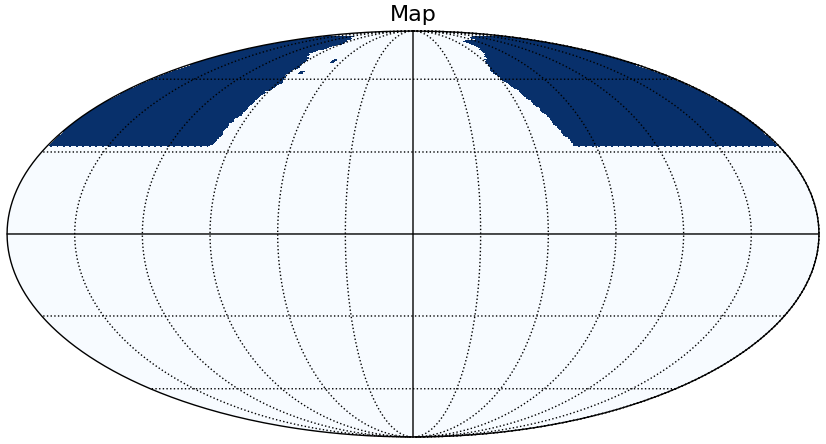

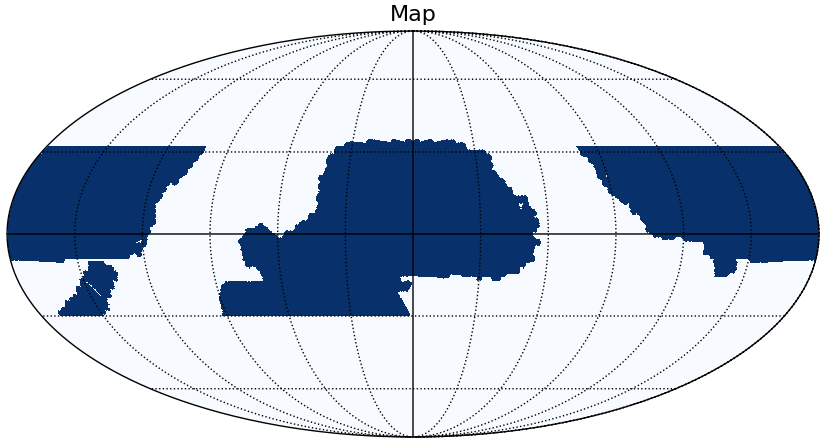

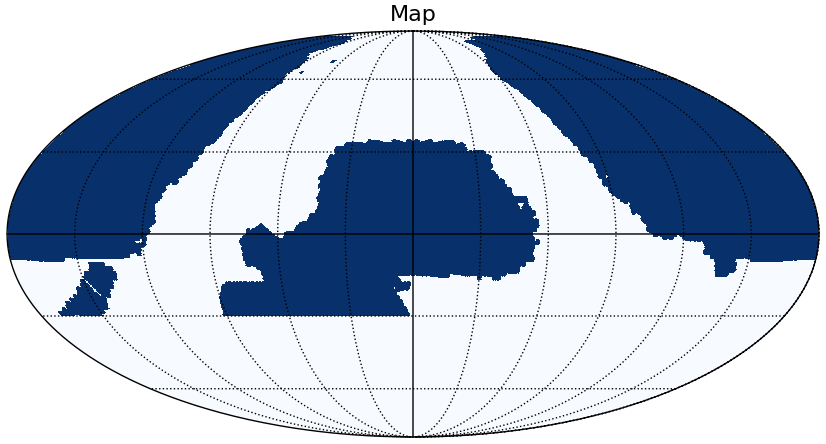

In [38]:
plot_map(north_masks[512],512)
plot_map(south_masks[256],256)
plot_map(full_masks[1024],1024)

In [39]:
data_map = points_to_map(RA_data, DEC_data, nside, None)
mask=np.load('../cl_estimate_backup/mask_dense.npy')

#mask = np.load('/user/animesh.sah/DESI_PECVEL/mask_full.npy')
data_north = points_to_map(ra_north, dec_north, nside, None)
data_south = points_to_map(ra_south, dec_south, nside,
    None)   

mask_north = np.load('/user/animesh.sah/DESI_PECVEL/mask_north.npy')
mask_south = np.load('/user/animesh.sah/DESI_PECVEL/mask_south.npy')

In [52]:
def get_cl(data_map,mask,nside=1024,lmax=1000):
    npix= 12*nside**2
    tot1=np.sum(mask)
    tot2=np.sum(data_map)
    fsky=tot1/npix
    rntot1=np.copy(tot2)
    ll=np.arange(0,lmax+1)
    map1=mask*(data_map*tot1/tot2 - 1)
    a1=hp.map2alm(map1,lmax=lmax)
    p1=hp.alm2cl(a1)
    dl1=ll*(ll+1)/2/np.pi*p1/fsky
    pshot=2*fsky*ll*(1+ll)/rntot1
    dl1 = dl1 - pshot
    return dl1,pshot,fsky,rntot1

def bin_cl(dl1,pshot1,fsky,rntot1,nell=10,lmax=1000):
    bins = np.arange(nell, lmax+nell, nell)
    bin_centers= (bins[1:]+bins[:-1])/2
    #bin_centers = np.r_[bins[0]/2,bin_centers]
    breakpoints=np.arange(nell,len(dl1)-1,nell)+1
    #starts = np.r_[0,breakpoints]
    sums = np.add.reduceat(dl1, breakpoints)
    sumsq = np.add.reduceat(dl1**2, breakpoints)
    pshot1 = 2*fsky*bin_centers * (1+bin_centers)/rntot1 
    dCl = np.sqrt(sumsq/nell  - (sums**2)/nell**2)/(np.sqrt(fsky))/np.sqrt(nell-1)
    Cl = sums/nell # - pshot1
    return bin_centers,Cl,dCl

# plt.plot(dl1,'.')
# dl1=dl1-pshot
# plt.plot(dl1,'.')


In [8]:
# d1 is an array of CL values for l values from 0 to lmax
# Now we will bin these CL values in bins of size nell=10

In [7]:
bin_centers,Cl,dCl = bin_cl(*get_cl(data_map,mask),nell=10)
bin_north, Cl_north, dCl_north = bin_cl(*get_cl(data_north,mask_north),nell=10) 
bin_south, Cl_south, dCl_south = bin_cl(*get_cl(data_south,mask_south),nell=10)


Text(0.5, 1.0, 'Angular Power Spectrum')

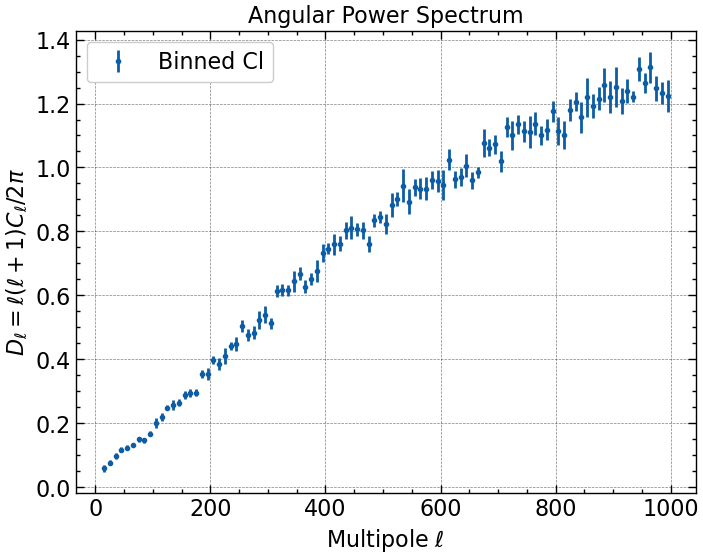

In [8]:
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
#plt.yscale('log')
plt.legend()
plt.title('Angular Power Spectrum')

Text(0.5, 1.0, 'Angular Power Spectrum')

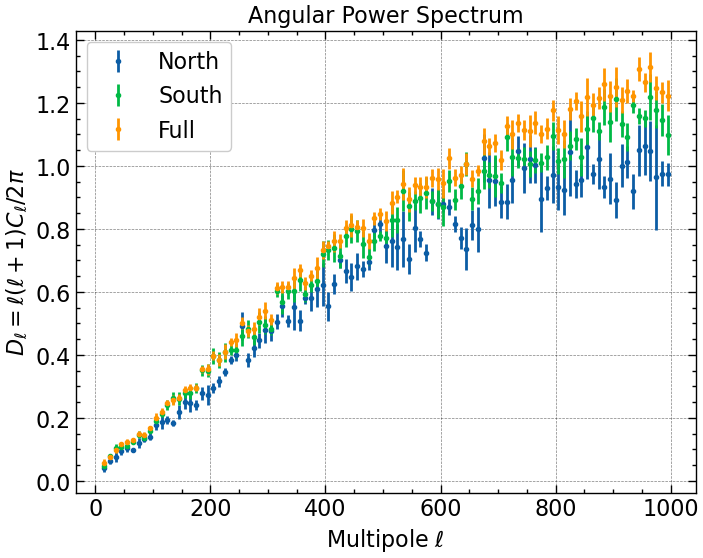

In [9]:
plt.errorbar(bin_north,Cl_north,yerr=dCl_north,fmt='.',label='North')
plt.errorbar(bin_south,Cl_south,yerr=dCl_south,fmt='.',label='South')
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Full')

plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/  2\pi$')
#plt.yscale('log')
plt.legend()
plt.title('Angular Power Spectrum')

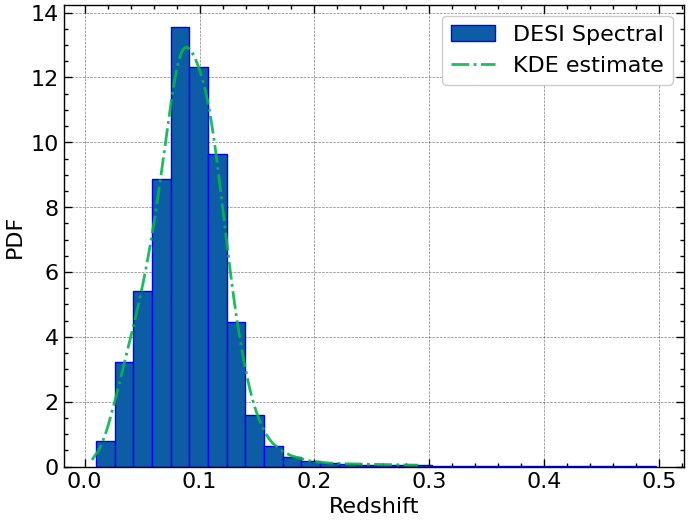

In [49]:
from scipy.stats import gaussian_kde
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'-.',alpha=0.9,label='KDE estimate')
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.legend()
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)


In [50]:
cosmo = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index
)

cosmo_hmcode = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index,
    ,matter_power_spectrum="camb",
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",

        }
    }

)


z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo_hmcode, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell = np.arange(0, 1000)
cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
dl = ell*(ell+1)*cls_gg/2/np.pi

def dll(ell,a):
    gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, a*np.ones_like(z)))
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return dl 

def dll_hm(ell,a):
    gal_tracer_2 = ccl.NumberCountsTracer(cosmo_hmcode, has_rsd=False, dndz=(z, n_z), bias=(z, a*np.ones_like(z)))
    cls_gg = ccl.angular_cl(cosmo_hmcode, gal_tracer_2, gal_tracer_2, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return dl

In [55]:
# ell = np.arange(0, 400)
# #plt.plot(bin_centers[bin_centers<300],dll(1.6,bin_centers[bin_centers<300]),label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
# plt.plot(ell,dll(ell,2.55),'--',label='Bestfit from pyccl (bias={:.2f})'.format(np.sqrt(popt[0])))
# plt.plot(bin_centers[bin_centers<300],Cl[bin_centers<300],label='Binned Cl',marker= '.',ls='None')
# popt1,pcov1=cf(dll_hm,bin_centers[bin_centers<200],Cl[bin_centers<200],sigma=dCl[bin_centers<200],p0=[3])
# plt.plot(ell,dll_hm(ell,popt1),':',label='Bestfit from HMCode (bias={:.2f})'.format(np.sqrt(popt1[0])))
# plt.legend()

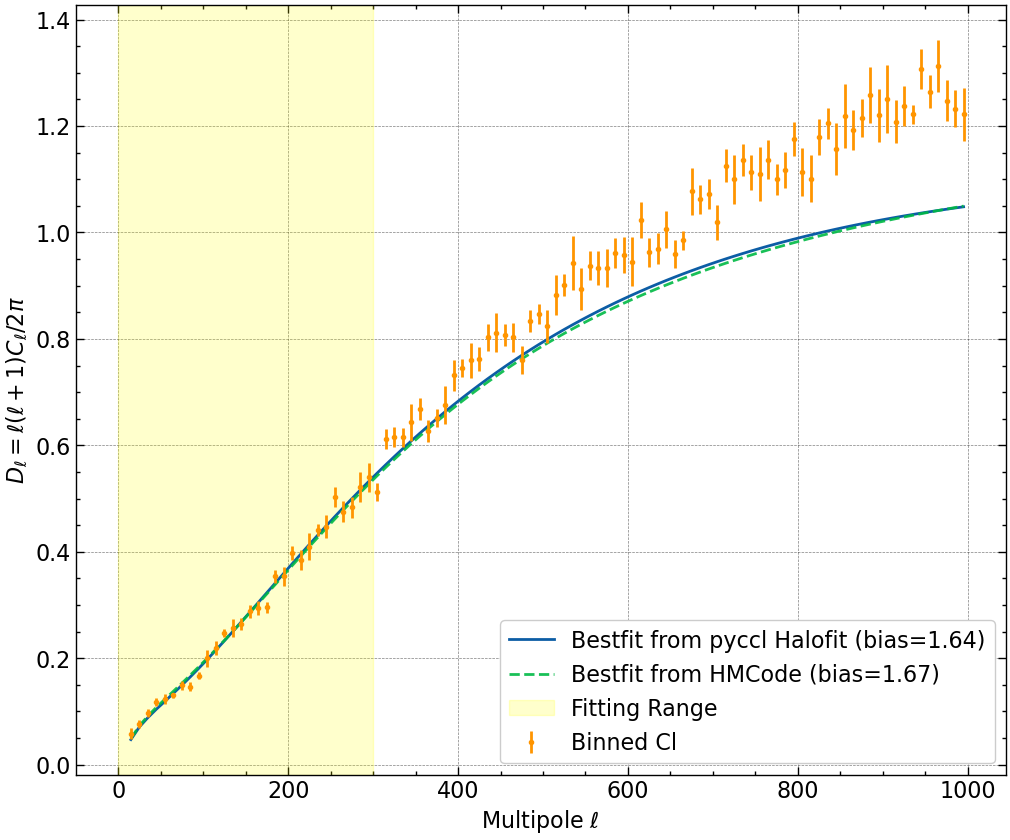

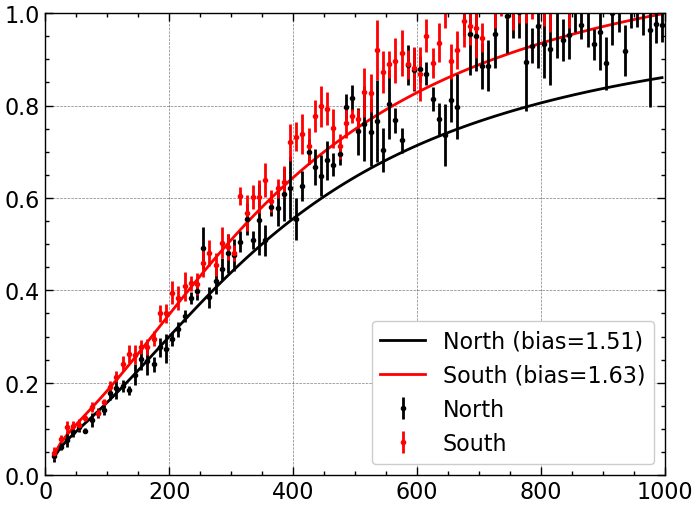

In [35]:
plt.figure(figsize=(12,10))
popt,pcov=cf(dll,bin_centers[bin_centers<300],Cl[bin_centers<300],sigma=dCl[bin_centers<300],p0=[2.25])
popt_hm,pcov_hm=cf(dll_hm,bin_centers[bin_centers<300],Cl[bin_centers<300],sigma=dCl[bin_centers<300],p0=[2.25])

plt.plot(bin_centers,dll(bin_centers,popt),label='Bestfit from pyccl Halofit (bias={:.2f})'.format(popt[0]))
plt.plot(bin_centers,dll_hm(bin_centers,popt_hm),label='Bestfit from HMCode (bias={:.2f})'.format(popt_hm[0]),ls='--',alpha=0.9)
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')

plt.axvspan(0,300,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()


plt.show()
poptn,pcovn = cf(dll_hm,bin_north[bin_north<300],Cl_north[bin_north<300],sigma=dCl_north[bin_north<300],p0=[2])
popts,pcovs = cf(dll_hm,bin_south[bin_south<300],Cl_south[bin_south<300],sigma=dCl_south[bin_south<300],p0=[2])
plt.plot(bin_north,dll_hm(bin_north,poptn),label='North (bias={:.2f})'.format(poptn[0]),color='k')
plt.plot(bin_south,dll_hm(bin_south,popts),label='South (bias={:.2f})'.format(popts[0]),color='r')
plt.errorbar(bin_north,Cl_north,yerr=dCl_north,fmt='.',label='North',color='k')
plt.errorbar(bin_south,Cl_south,yerr=dCl_south,fmt='.',label='South',color='r')
plt.xlim(0,1000)         
plt.ylim(0,1)
plt.legend()



Length of current data and mask: 786432 786432 for nside= 256
Length of current data and mask: 3145728 3145728 for nside= 512
Length of current data and mask: 12582912 12582912 for nside= 1024
Length of current data and mask: 50331648 50331648 for nside= 2048


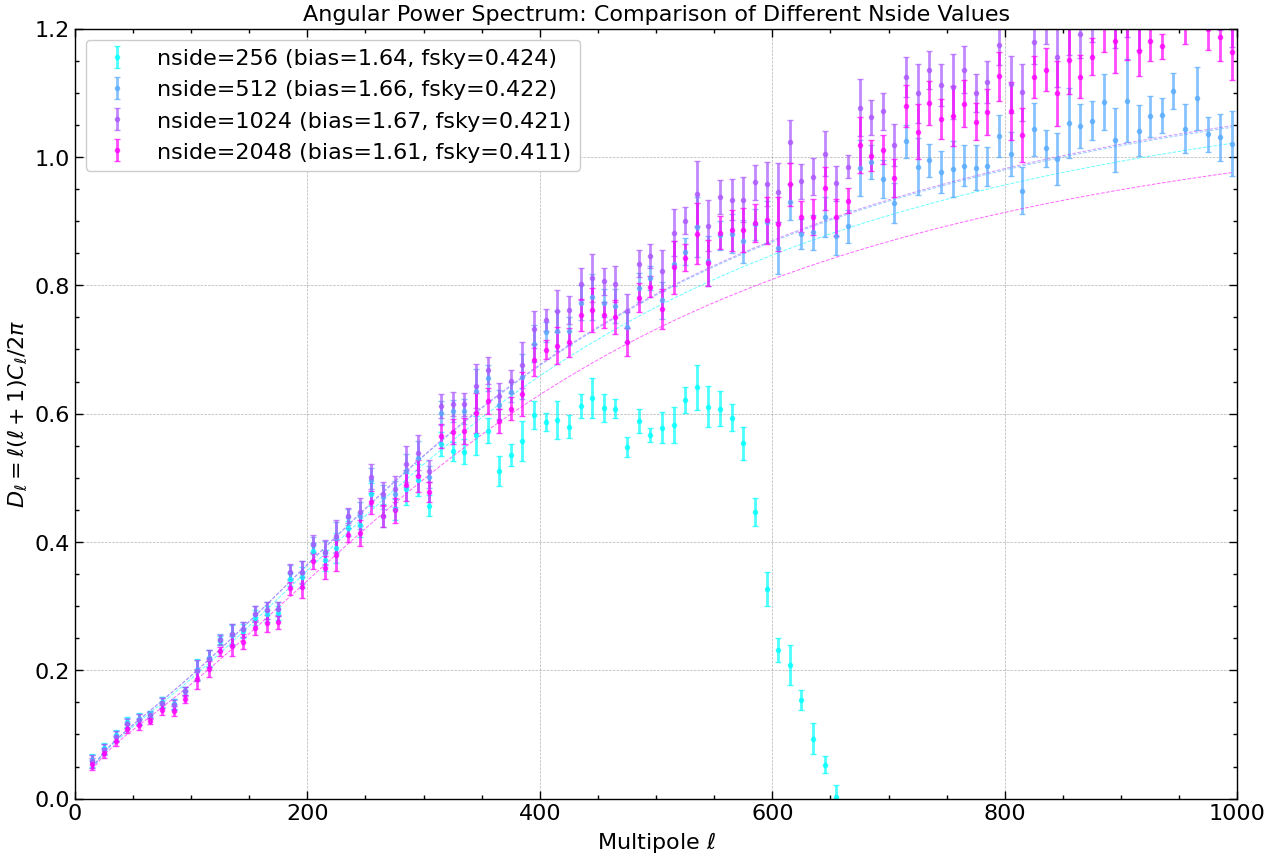


Summary of results:
--------------------------------------------------
nside=256: bias=1.644, fsky=0.4242
nside=512: bias=1.664, fsky=0.4221
nside=1024: bias=1.665, fsky=0.4210
nside=2048: bias=1.606, fsky=0.4107


In [64]:
# Analysis with different nside values
nside_values = [256, 512, 1024, 2048]
results = {}

plt.figure(figsize=(15, 10))

colors = plt.cm.cool(np.linspace(0, 1, len(nside_values)))
for i, ns in enumerate(nside_values):
    # Create mask for this nside

        # Create new data map and use existing mask from full_masks
    current_data = points_to_map(RA_data, DEC_data, ns, None)
    current_mask = full_masks[ns]
    print('Length of current data and mask:', len(current_data), len(current_mask),'for nside=',ns)
    # Compute angular power spectrum
    dl, pshot, fsky, rntot = get_cl(current_data, current_mask, nside=ns, lmax=1000)
    
    # Bin the results
    bin_cent, Cl_binned, dCl_binned = bin_cl(dl, pshot, fsky, rntot, nell=10, lmax=1000)
    
    # Fit to theory (using ell < 300)
    mask_fit = bin_cent < 300
    popt_fit, pcov_fit = cf(dll_hm, bin_cent[mask_fit], Cl_binned[mask_fit], 
                            sigma=dCl_binned[mask_fit], p0=[2])
    
    # Store results
    results[ns] = {
        'bin_centers': bin_cent,
        'Cl': Cl_binned,
        'dCl': dCl_binned,
        'bias': popt_fit[0],
        'fsky': fsky
    }
    
    # Plot
    plt.errorbar(bin_cent, Cl_binned, yerr=dCl_binned, fmt='.', 
                label=f'nside={ns} (bias={popt_fit[0]:.2f}, fsky={fsky:.3f})', alpha=0.7,color= colors[i],capsize=2)
    plt.plot(bin_cent, dll_hm(bin_cent, popt_fit), '--', alpha=0.6,color= colors[i],lw=0.7)

plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.xlim(0,1000)
plt.ylim(0, 1.2)
plt.legend()
plt.title('Angular Power Spectrum: Comparison of Different Nside Values')
plt.grid(True, alpha=0.3)
plt.show()

# Print summary
print("\nSummary of results:")
print("-" * 50)
for ns in nside_values:
    print(f"nside={ns}: bias={results[ns]['bias']:.3f}, fsky={results[ns]['fsky']:.4f}")

North - nside=256: data length=786432, mask length=786432
North - nside=512: data length=3145728, mask length=3145728
North - nside=1024: data length=12582912, mask length=12582912
North - nside=2048: data length=50331648, mask length=50331648
South - nside=256: data length=786432, mask length=786432
South - nside=512: data length=3145728, mask length=3145728
South - nside=1024: data length=12582912, mask length=12582912
South - nside=2048: data length=50331648, mask length=50331648


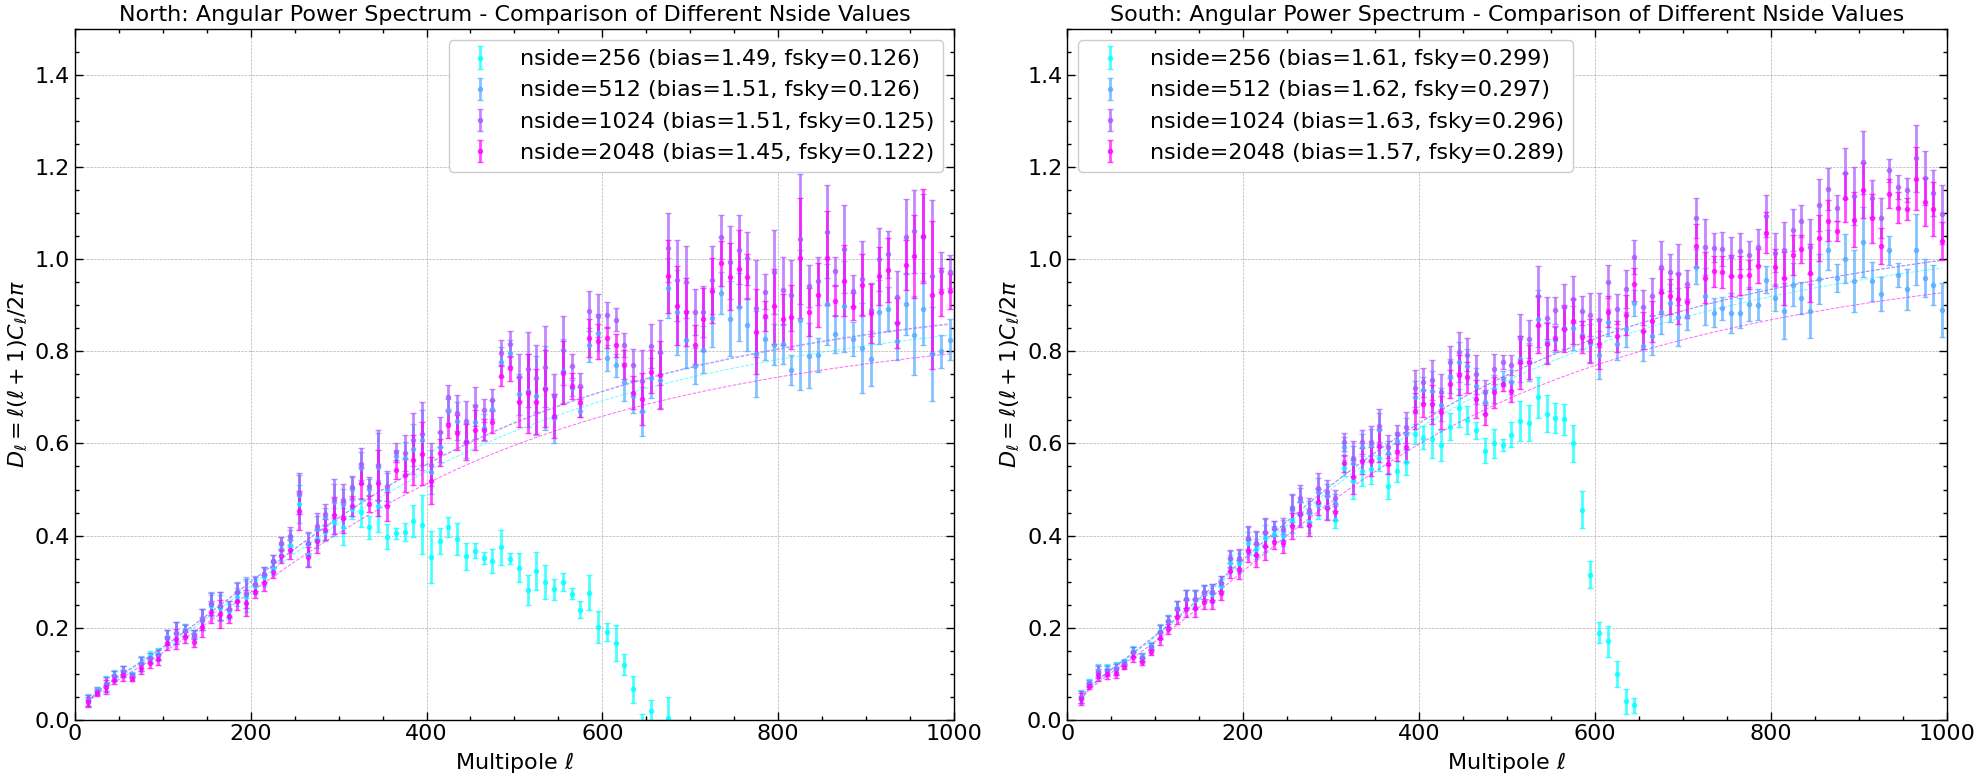


NORTH - Summary of results:
----------------------------------------------------------------------
nside=256: bias=1.486, fsky=0.1264
nside=512: bias=1.507, fsky=0.1255
nside=1024: bias=1.509, fsky=0.1253
nside=2048: bias=1.450, fsky=0.1221

SOUTH - Summary of results:
----------------------------------------------------------------------
nside=256: bias=1.611, fsky=0.2991
nside=512: bias=1.625, fsky=0.2972
nside=1024: bias=1.625, fsky=0.2961
nside=2048: bias=1.566, fsky=0.2886


In [65]:
# Analysis with different nside values for North and South
nside_values = [256, 512, 1024, 2048]
results_north = {}
results_south = {}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

colors = plt.cm.cool(np.linspace(0, 1, len(nside_values)))

# North analysis
for i, ns in enumerate(nside_values):
    # Create data map for north
    current_data_north = points_to_map(ra_north, dec_north, ns, None)
    current_mask_north = north_masks[ns]
    print(f'North - nside={ns}: data length={len(current_data_north)}, mask length={len(current_mask_north)}')
    
    # Compute angular power spectrum
    dl_n, pshot_n, fsky_n, rntot_n = get_cl(current_data_north, current_mask_north, nside=ns, lmax=1000)
    
    # Bin the results
    bin_cent_n, Cl_binned_n, dCl_binned_n = bin_cl(dl_n, pshot_n, fsky_n, rntot_n, nell=10, lmax=1000)
    
    # Fit to theory (using ell < 300)
    mask_fit_n = bin_cent_n < 300
    popt_fit_n, pcov_fit_n = cf(dll_hm, bin_cent_n[mask_fit_n], Cl_binned_n[mask_fit_n], 
                                sigma=dCl_binned_n[mask_fit_n], p0=[2])
    
    # Store results
    results_north[ns] = {
        'bin_centers': bin_cent_n,
        'Cl': Cl_binned_n,
        'dCl': dCl_binned_n,
        'bias': popt_fit_n[0],
        'fsky': fsky_n
    }
    
    # Plot
    ax1.errorbar(bin_cent_n, Cl_binned_n, yerr=dCl_binned_n, fmt='.', 
                label=f'nside={ns} (bias={popt_fit_n[0]:.2f}, fsky={fsky_n:.3f})', 
                alpha=0.7, color=colors[i], capsize=2)
    ax1.plot(bin_cent_n, dll_hm(bin_cent_n, popt_fit_n), '--', alpha=0.6, color=colors[i], lw=0.7)

# South analysis
for i, ns in enumerate(nside_values):
    # Create data map for south
    current_data_south = points_to_map(ra_south, dec_south, ns, None)
    current_mask_south = south_masks[ns]
    print(f'South - nside={ns}: data length={len(current_data_south)}, mask length={len(current_mask_south)}')
    
    # Compute angular power spectrum
    dl_s, pshot_s, fsky_s, rntot_s = get_cl(current_data_south, current_mask_south, nside=ns, lmax=1000)
    
    # Bin the results
    bin_cent_s, Cl_binned_s, dCl_binned_s = bin_cl(dl_s, pshot_s, fsky_s, rntot_s, nell=10, lmax=1000)
    
    # Fit to theory (using ell < 300)
    mask_fit_s = bin_cent_s < 300
    popt_fit_s, pcov_fit_s = cf(dll_hm, bin_cent_s[mask_fit_s], Cl_binned_s[mask_fit_s], 
                                sigma=dCl_binned_s[mask_fit_s], p0=[2])
    
    # Store results
    results_south[ns] = {
        'bin_centers': bin_cent_s,
        'Cl': Cl_binned_s,
        'dCl': dCl_binned_s,
        'bias': popt_fit_s[0],
        'fsky': fsky_s
    }
    
    # Plot
    ax2.errorbar(bin_cent_s, Cl_binned_s, yerr=dCl_binned_s, fmt='.', 
                label=f'nside={ns} (bias={popt_fit_s[0]:.2f}, fsky={fsky_s:.3f})', 
                alpha=0.7, color=colors[i], capsize=2)
    ax2.plot(bin_cent_s, dll_hm(bin_cent_s, popt_fit_s), '--', alpha=0.6, color=colors[i], lw=0.7)

# Configure North plot
ax1.set_xlabel(r'Multipole $\ell$')
ax1.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
ax1.set_xlim(0, 1000)
ax1.set_ylim(0, 1.5)
ax1.legend()
ax1.set_title('North: Angular Power Spectrum - Comparison of Different Nside Values')
ax1.grid(True, alpha=0.3)

# Configure South plot
ax2.set_xlabel(r'Multipole $\ell$')
ax2.set_ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
ax2.set_xlim(0, 1000)
ax2.set_ylim(0, 1.5)
ax2.legend()
ax2.set_title('South: Angular Power Spectrum - Comparison of Different Nside Values')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("NORTH - Summary of results:")
print("-" * 70)
for ns in nside_values:
    print(f"nside={ns}: bias={results_north[ns]['bias']:.3f}, fsky={results_north[ns]['fsky']:.4f}")

print("\n" + "="*70)
print("SOUTH - Summary of results:")
print("-" * 70)
for ns in nside_values:
    print(f"nside={ns}: bias={results_south[ns]['bias']:.3f}, fsky={results_south[ns]['fsky']:.4f}")

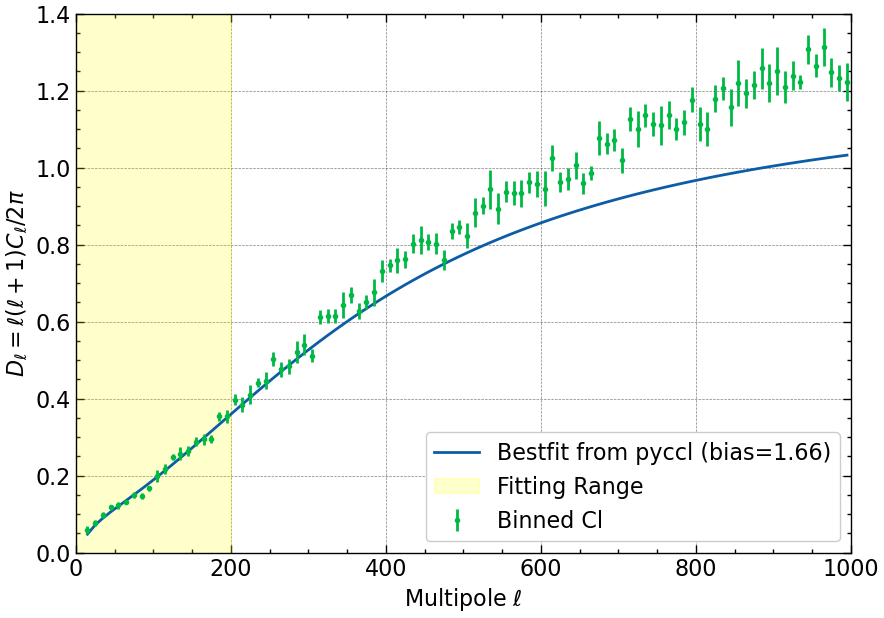

In [36]:
plt.figure(figsize=(10,7))

popt,pcov=cf(dll_hm,bin_centers[bin_centers<200],Cl[bin_centers<200],sigma=dCl[bin_centers<200],p0=[2])


plt.plot(bin_centers,dll_hm(bin_centers,popt),label='Bestfit from pyccl (bias={:.2f})'.format(popt[0]))
plt.errorbar(bin_centers,Cl,yerr=dCl,fmt='.',label='Binned Cl')
plt.xlim(0,1000)
plt.ylim(0,1.4)
plt.axvspan(0,200,alpha=0.2,color='yellow',label='Fitting Range')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')
plt.legend()

Text(0, 0.5, '$D_\\ell = \\ell(\\ell+1)C_\\ell/2\\pi$')

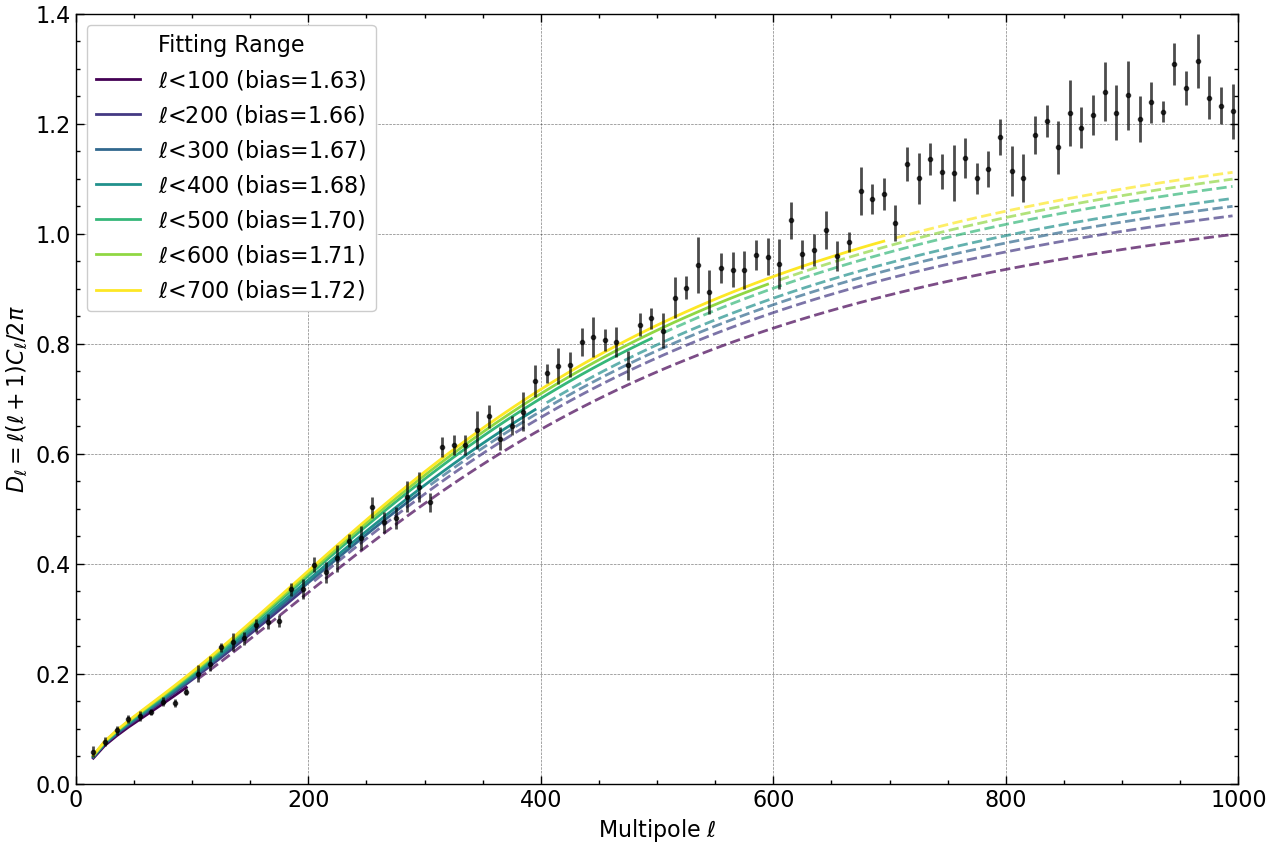

In [37]:
plt.figure(figsize=(15,10))

# Define fitting ranges
fit_ranges = [100,200, 300, 400, 500, 600,700]
colors = plt.cm.viridis(np.linspace(0, 1, len(fit_ranges)))

# Perform fits and plot for each range
for i, fit_max in enumerate(fit_ranges):
    # Fit the data
    popt, pcov = cf(dll_hm, bin_centers[bin_centers<fit_max], Cl[bin_centers<fit_max], 
                    sigma=dCl[bin_centers<fit_max], p0=[2])
    
    # Plot solid line up to fit range
    mask_fit = bin_centers <= fit_max
    plt.plot(bin_centers[mask_fit], dll_hm(bin_centers[mask_fit], popt), 
             color=colors[i], linestyle='-', 
             label=fr'$\ell$<{fit_max} (bias={popt[0]:.2f})')
    
    # Plot dotted line beyond fit range
    mask_beyond = bin_centers > fit_max
    plt.plot(bin_centers[mask_beyond], dll_hm(bin_centers[mask_beyond], popt), 
             color=colors[i], linestyle='--', alpha=0.7)

# Plot the actual data
plt.legend(title='Fitting Range')

plt.errorbar(bin_centers, Cl, yerr=dCl, fmt='.', label='Binned Cl', color='black', alpha=0.7)
plt.xlim(0, 1000)
plt.ylim(0, 1.4)
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/2\pi$')


In [121]:
north_0_04 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.04.fits')[1].read())
ra_north,dec_north = north_0_04['RA'], north_0_04['DEC']  
data_0_04 = points_to_map(ra_north, dec_north, nside, None)
north_0_01 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.01.fits')[1].read())
ra_north,dec_north = north_0_01['RA'], north_0_01['DEC']  
data_0_01 = points_to_map(ra_north, dec_north, nside, None)
north_0_0234 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.0234.fits')[1].read())
ra_north,dec_north = north_0_0234['RA'], north_0_0234['DEC']  
data_0_0234 = points_to_map(ra_north, dec_north, nside, None)
north_0_03 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_0.03.fits')[1].read())
ra_north,dec_north = north_0_03['RA'], north_0_03['DEC']  
data_0_03 = points_to_map(ra_north, dec_north, nside, None)
north_min_0_04 = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/north_cuts_v9_zeropoint_shifted_-0.04.fits')[1].read())
ra_north,dec_north = north_min_0_04['RA'], north_min_0_04['DEC']
data_min_0_04 = points_to_map(ra_north, dec_north, nside, None)



In [122]:
bin_north, Cl_0_04, dCl_0_04 = bin_cl(*get_cl(data_0_04, mask_north), nell=10)
bin_north, Cl_0_01, dCl_0_01 = bin_cl(*get_cl(data_0_01, mask_north), nell=10)
bin_north, Cl_0_0234, dCl_0_0234 = bin_cl(*get_cl(data_0_0234, mask_north), nell=10)    
bin_north, Cl_0_03, dCl_0_03 = bin_cl(*get_cl(data_0_03, mask_north), nell=10)
bin_north, Cl_min_0_04, dCl_min_0_04 =      bin_cl(*get_cl(data_min_0_04, mask_north), nell=10)


Text(0.5, 1.0, 'Angular Power Spectrum')

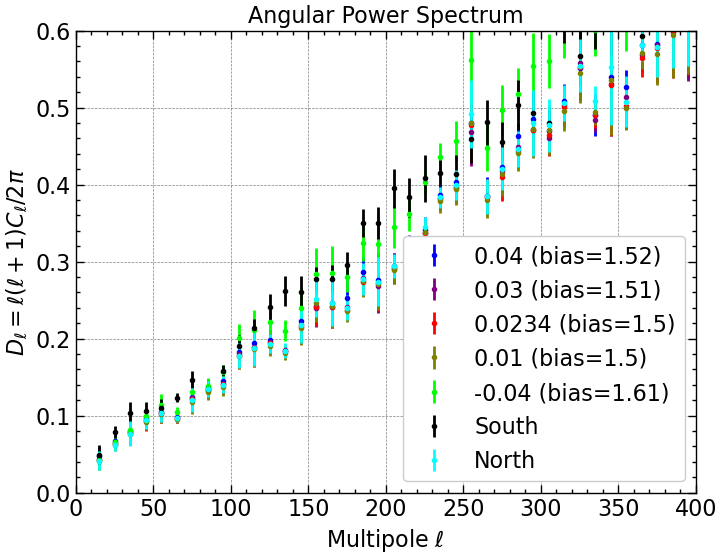

In [123]:
colors = plt.cm.brg(np.linspace(0, 1, 5))
popt_0_04,pcov_0_04=cf(dll,bin_north[bin_north<300],Cl_0_04[bin_north<300],sigma=dCl_0_04[bin_north<300],p0=[2])
popt_0_03,pcov_0_03=cf(dll,bin_north[bin_north<300],Cl_0_03[bin_north<300],sigma=dCl_0_03[bin_north<300],p0=[2])
popt_0_0234,pcov_0_0234=cf(dll,bin_north[bin_north<300],Cl_0_0234[bin_north<300],sigma=dCl_0_0234[bin_north<300],p0=[2])
popt_0_01,pcov_0_01=cf(dll,bin_north[bin_north<300],Cl_0_01[bin_north<300],sigma=dCl_0_01[bin_north<300],p0=[2])
popt_min_0_04,pcov_min_0_04=cf(dll,bin_north[bin_north<300],Cl_min_0_04[bin_north<300],sigma=dCl_min_0_04[bin_north<300],p0=[2])

plt.errorbar(bin_north,Cl_0_04,yerr=dCl_0_04,fmt='.',label=f'0.04 (bias={round(np.sqrt(popt_0_04[0]),2)})',color=colors[0])
plt.errorbar(bin_north,Cl_0_03,yerr=dCl_0_03,fmt='.',label=f'0.03 (bias={round(np.sqrt(popt_0_03[0]),2)})',color=colors[1])
plt.errorbar(bin_north,Cl_0_0234,yerr=dCl_0_0234,fmt='.',label=f'0.0234 (bias={round(np.sqrt(popt_0_0234[0]),2)})',color=colors[2])
plt.errorbar(bin_north,Cl_0_01,yerr=dCl_0_01,fmt='.',label=f'0.01 (bias={round(np.sqrt(popt_0_01[0]),2)})',color=colors[3])
plt.errorbar(bin_north,Cl_min_0_04,yerr=dCl_min_0_04,fmt='.',label=f'-0.04 (bias={round(np.sqrt(popt_min_0_04[0]),2)})',color=colors[4])
plt.errorbar(bin_south,Cl_south,yerr=dCl_south,fmt='.',label='South',color='k')
plt.errorbar(bin_north,Cl_north,yerr=dCl_north,fmt='.',label='North',color='cyan')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell = \ell(\ell+1)C_\ell/  2\pi$')
#plt.yscale('log')
plt.legend()
plt.xlim(0,400)         
plt.ylim(0,0.6)
plt.title('Angular Power Spectrum') 

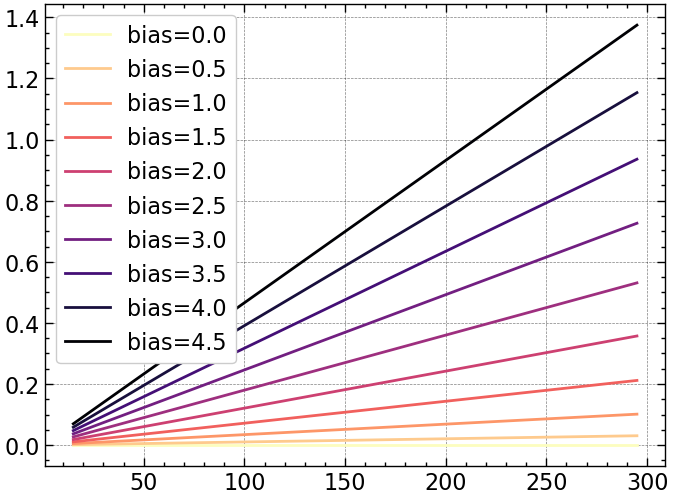

In [125]:
colors = plt.cm.magma_r(np.linspace(0, 1, 10))

for i in range(10):
    plt.plot(bin_north[bin_north<300],dll(i*0.5,bin_north[bin_north<300] ), color=colors[i],label=f'bias={i*0.5}')
plt.legend()